#  Hospital Readmission Risk Analytics
## Notebook 1: EDA & Data Preparation
### Diabetes 130-US Hospitals Dataset (UCI, 1999–2008)

---

###  Project Overview

Hospital readmission within 30 days is a critical healthcare quality metric targeted by
the **Hospital Readmissions Reduction Program (HRRP)**. Hospitals face financial penalties
for excessive readmission rates. Predicting which patients are at risk allows clinicians
to intervene **before** discharge.

**This project builds a full ML pipeline across 4 notebooks:**

| Notebook | Content |
|----------|---------|
| 1 — This one | EDA, data cleaning, feature engineering |
| 2 — Logistic Regression | Baseline model, coefficients, ROC |
| 3 — Random Forest | Ensemble model, feature importances, threshold tuning |
| 4 — XGBoost + SHAP | Best model, SHAP explainability, model comparison |

---


In [1]:
#  Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)

print(" Libraries loaded")
print("   pandas:", pd.__version__)
print("   numpy :", np.__version__)

✅ Libraries loaded
   pandas: 3.0.3
   numpy : 2.4.4


---
## 1. Load the Dataset

In [2]:
# Load raw data
# Replace '?' (used for unknown values) with NaN at load time
df_raw = pd.read_csv("C:\\Users\\PC\\Downloads\\diabetes+130-us+hospitals+for+years+1999-2008\\diabetic_data.csv", na_values=["?"])

print(f"Raw dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print()
df_raw.head()

Raw dataset shape: 101,766 rows × 50 columns



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Column overview
print("Column data types:")
print(df_raw.dtypes.value_counts())
print()
print("All columns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>2}. {col}")

Column data types:
str      37
int64    13
Name: count, dtype: int64

All columns:
   1. encounter_id
   2. patient_nbr
   3. race
   4. gender
   5. age
   6. weight
   7. admission_type_id
   8. discharge_disposition_id
   9. admission_source_id
  10. time_in_hospital
  11. payer_code
  12. medical_specialty
  13. num_lab_procedures
  14. num_procedures
  15. num_medications
  16. number_outpatient
  17. number_emergency
  18. number_inpatient
  19. diag_1
  20. diag_2
  21. diag_3
  22. number_diagnoses
  23. max_glu_serum
  24. A1Cresult
  25. metformin
  26. repaglinide
  27. nateglinide
  28. chlorpropamide
  29. glimepiride
  30. acetohexamide
  31. glipizide
  32. glyburide
  33. tolbutamide
  34. pioglitazone
  35. rosiglitazone
  36. acarbose
  37. miglitol
  38. troglitazone
  39. tolazamide
  40. examide
  41. citoglipton
  42. insulin
  43. glyburide-metformin
  44. glipizide-metformin
  45. glimepiride-pioglitazone
  46. metformin-rosiglitazone
  47. metformin-pioglitazon

---
## 2. Missing Value Analysis

Columns with missing values:
                   Missing N  Missing %
weight                 98569      96.86
max_glu_serum          96420      94.75
A1Cresult              84748      83.28
medical_specialty      49949      49.08
payer_code             40256      39.56
race                    2273       2.23
diag_3                  1423       1.40
diag_2                   358       0.35
diag_1                    21       0.02


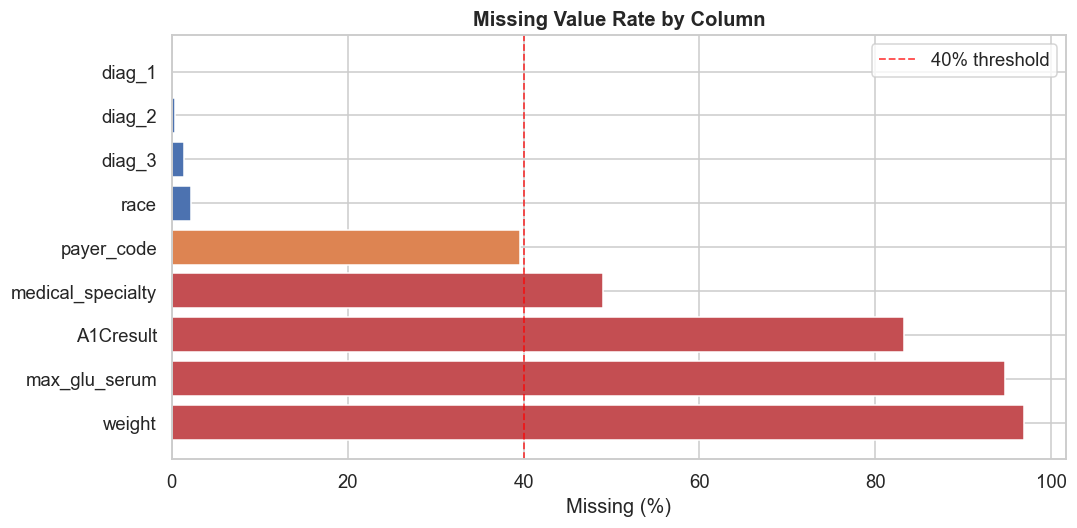


 Missing Value Rate by Column Plot saved to outputs/figures/


<Figure size 1320x550 with 0 Axes>

In [21]:
# Count and visualise missing values (remember '?' was already converted to NaN)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Missing N": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing N"] > 0].sort_values("Missing %", ascending=False)

print("Columns with missing values:")
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C44E52" if p > 40 else "#DD8452" if p > 10 else "#4C72B0"
          for p in missing_df["Missing %"]]
ax.barh(missing_df.index, missing_df["Missing %"], color=colors, edgecolor="white")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Value Rate by Column", fontweight="bold")
ax.axvline(40, color="red", linestyle="--", lw=1.2, alpha=0.7, label="40% threshold")
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig(
    "Outputs/figures/Missing_Value_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Missing Value Rate by Column Plot saved to outputs/figures/")

---
## 3. Data Cleaning


In [27]:
df = df_raw.copy()

# ── Step 1: Drop high-missingness & low-signal columns
# weight: 97% missing | payer_code: not clinically useful
drop_cols = ["weight", "payer_code", "medical_specialty"]
df.drop(columns=drop_cols, inplace=True)
print(f"Step 1 — Dropped columns: {drop_cols}")

# ── Step 2: Remove deaths & hospice discharges
# discharge_disposition_id: 11=Expired, 13/14=Hospice
before = len(df)
df = df[~df["discharge_disposition_id"].isin([11, 13, 14])]
print(f"Step 2 — Removed deaths/hospice: {before - len(df):,} rows removed")

# ── Step 3: Keep only FIRST encounter per patient
before = len(df)
df = df.sort_values("encounter_id").drop_duplicates(subset="patient_nbr", keep="first")
print(f"Step 3 — Kept first encounter per patient: {before - len(df):,} duplicates removed")

# ── Step 4: Drop ID columns (not predictive)
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)
print(f"Step 4 — Dropped ID columns")

print(f"\n Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Step 1 — Dropped columns: ['weight', 'payer_code', 'medical_specialty']
Step 2 — Removed deaths/hospice: 2,413 rows removed
Step 3 — Kept first encounter per patient: 29,356 duplicates removed
Step 4 — Dropped ID columns

✅ Clean dataset: 69,997 rows × 45 columns


---
## 4. Target Variable Engineering

Binary target distribution:
  Readmitted <30 days :   6,285 (9.0%)
  Not readmitted      :  63,712 (91.0%)


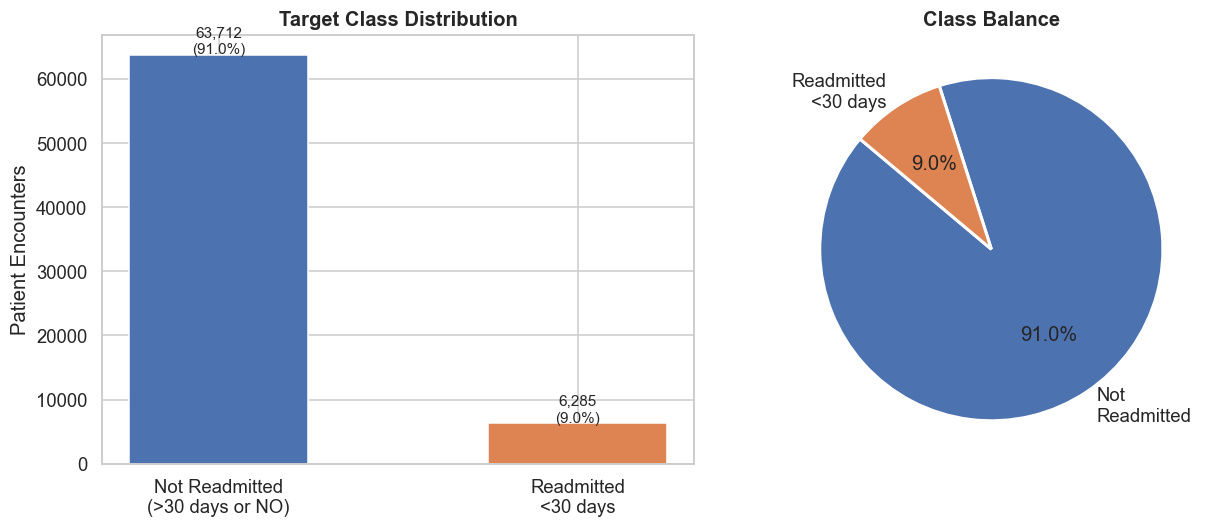

✅ Plot saved under outputs/figures/


In [31]:
# Binary target distribution
print("Binary target distribution:")

counts = df["readmit_30"].value_counts()

rate = df["readmit_30"].mean() * 100

print(f"  Readmitted <30 days : {counts[1]:>7,} ({rate:.1f}%)")
print(f"  Not readmitted      : {counts[0]:>7,} ({100-rate:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(
    ["Not Readmitted\n(>30 days or NO)", "Readmitted\n<30 days"],
    [counts[0], counts[1]],
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5
)

axes[0].set_ylabel("Patient Encounters")
axes[0].set_title("Target Class Distribution", fontweight="bold")

for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(
        i,
        v + 200,
        f"{v:,}\n({v/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10
    )

# Pie chart
axes[1].pie(
    [counts[0], counts[1]],
    labels=["Not\nReadmitted", "Readmitted\n<30 days"],
    colors=["#4C72B0", "#DD8452"],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[1].set_title("Class Balance", fontweight="bold")

plt.tight_layout()

# Save plot
import os
os.makedirs("outputs/figures", exist_ok=True)

plt.savefig(
    "outputs/figures/target_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(" Plot saved under outputs/figures/")

# ICD-09 Diagnosis Grouping

In [7]:
def map_icd9(code):
    """Map ICD-9 codes to clinical categories per Strack et al. (2014)."""
    if pd.isna(code):
        return "Other"
    code = str(code)
    # V and E codes
    if code.startswith("V") or code.startswith("E"):
        return "Other"
    try:
        c = float(code)
    except ValueError:
        return "Other"

    if 390 <= c <= 459 or c == 785:
        return "Circulatory"
    elif 460 <= c <= 519 or c == 786:
        return "Respiratory"
    elif 520 <= c <= 579 or c == 787:
        return "Digestive"
    elif c == 250:
        return "Diabetes"
    elif 800 <= c <= 999:
        return "Injury"
    elif 710 <= c <= 739:
        return "Musculoskeletal"
    elif 580 <= c <= 629 or c == 788:
        return "Genitourinary"
    elif 140 <= c <= 239:
        return "Neoplasms"
    else:
        return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[col + "_cat"] = df[col].apply(map_icd9)
    df.drop(columns=[col], inplace=True)

print("ICD-9 diagnosis categories:")
print(df["diag_1_cat"].value_counts())

ICD-9 diagnosis categories:
diag_1_cat
Circulatory        21392
Other              17683
Respiratory         9491
Digestive           6489
Injury              4699
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Diabetes             200
Name: count, dtype: int64


---
## 6. Feature Engineering

In [8]:
# Age as numeric midpoint
age_map = {"[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
           "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
           "[80-90)": 85, "[90-100)": 95}
df["age_numeric"] = df["age"].map(age_map)

#  Prior utilisation score (weighted)
df["prior_utilisation"] = (
    df["number_inpatient"] * 3 +
    df["number_emergency"] * 2 +
    df["number_outpatient"] * 1
)

#  Medication summary features
med_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide",
            "glimepiride", "acetohexamide", "glipizide", "glyburide",
            "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
            "miglitol", "troglitazone", "tolazamide", "examide",
            "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone"]

# Number of diabetes medications actively prescribed (not "No")
df["num_diabetes_meds"] = (df[med_cols] != "No").sum(axis=1)

# Number of medication changes (Up or Down)
df["num_med_changes"] = df[med_cols].isin(["Up", "Down"]).sum(axis=1)

# Insulin-specific features
df["insulin_used"]    = (df["insulin"] != "No").astype(int)
df["insulin_changed"] = df["insulin"].isin(["Up", "Down"]).astype(int)

#  Clinical flags
df["long_stay"]    = (df["time_in_hospital"] > 7).astype(int)
df["polypharmacy"] = (df["num_medications"] > 10).astype(int)
df["a1c_tested"]   = (df["A1Cresult"] != "None").astype(int)
df["a1c_high"]     = df["A1Cresult"].isin([">7", ">8"]).astype(int)
df["glucose_high"] = df["max_glu_serum"].isin([">200", ">300"]).astype(int)

print("Engineered features created:")
eng_feats = ["age_numeric", "prior_utilisation", "num_diabetes_meds",
             "num_med_changes", "insulin_used", "insulin_changed",
             "long_stay", "polypharmacy", "a1c_tested", "a1c_high", "glucose_high"]
print(df[eng_feats].describe().round(2))

Engineered features created:
       age_numeric  prior_utilisation  num_diabetes_meds  num_med_changes  \
count     69997.00           69997.00           69997.00         69997.00   
mean         65.44               1.02               1.19             0.26   
std          15.97               2.54               0.94             0.48   
min           5.00               0.00               0.00             0.00   
25%          55.00               0.00               1.00             0.00   
50%          65.00               0.00               1.00             0.00   
75%          75.00               1.00               2.00             0.00   
max          95.00              99.00               6.00             4.00   

       insulin_used  insulin_changed  long_stay  polypharmacy  a1c_tested  \
count      69997.00          69997.0   69997.00      69997.00     69997.0   
mean           0.51              0.2       0.14          0.72         1.0   
std            0.50              0.4       0.3

---
## 7. Exploratory Visualisations


 30-Day Readmission Rate by Age Group Plot saved to outputs/figures/


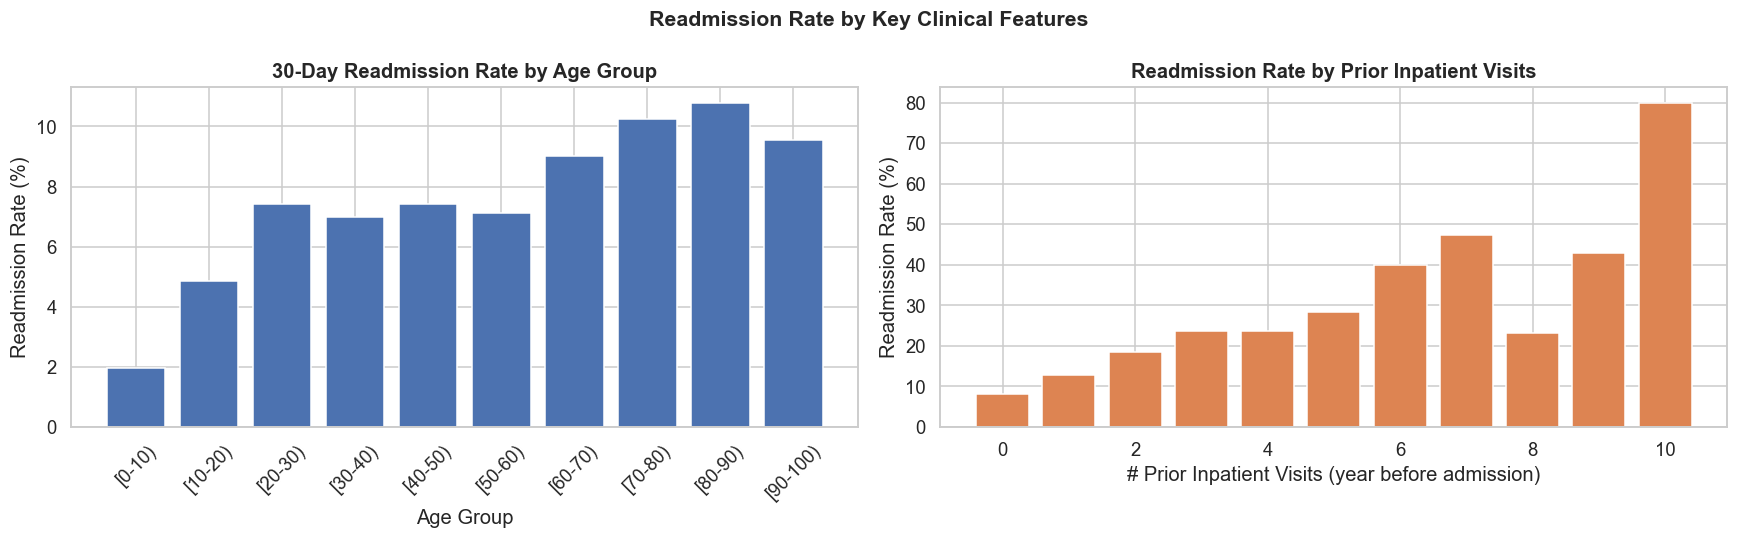


 Readmission Rate by Prior Inpatient Visits Plot saved to outputs/figures/


<Figure size 1320x550 with 0 Axes>

In [17]:
# Readmission rate across age groups
age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
             "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]
age_rate  = df.groupby("age")["readmit_30"].mean().reindex(age_order) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(age_order, age_rate, color="#4C72B0", edgecolor="white")
axes[0].set_title("30-Day Readmission Rate by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].tick_params(axis="x", rotation=45)
plt.savefig(
    "Outputs/figures/30-Day_Readmission_Rate_by_Age_Group.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n 30-Day Readmission Rate by Age Group Plot saved to outputs/figures/")

# Readmission rate by number of prior inpatient visits
inpat_rate = df.groupby("number_inpatient")["readmit_30"].mean() * 100
inpat_rate = inpat_rate[inpat_rate.index <= 10]
axes[1].bar(inpat_rate.index, inpat_rate.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Readmission Rate by Prior Inpatient Visits", fontweight="bold")
axes[1].set_xlabel("# Prior Inpatient Visits (year before admission)")
axes[1].set_ylabel("Readmission Rate (%)")

plt.suptitle("Readmission Rate by Key Clinical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(
    "Outputs/figures/Readmission_Rate_by_Prior_Inpatient_Visits.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Readmission Rate by Prior Inpatient Visits Plot saved to outputs/figures/")


 Readmission Rate by HbA1c Result Plot saved to outputs/figures/

 Readmission Rate vs Time in Hospital Plot saved to outputs/figures/

 Readmission Rate by Primary Diagnosis Plot saved to outputs/figures/


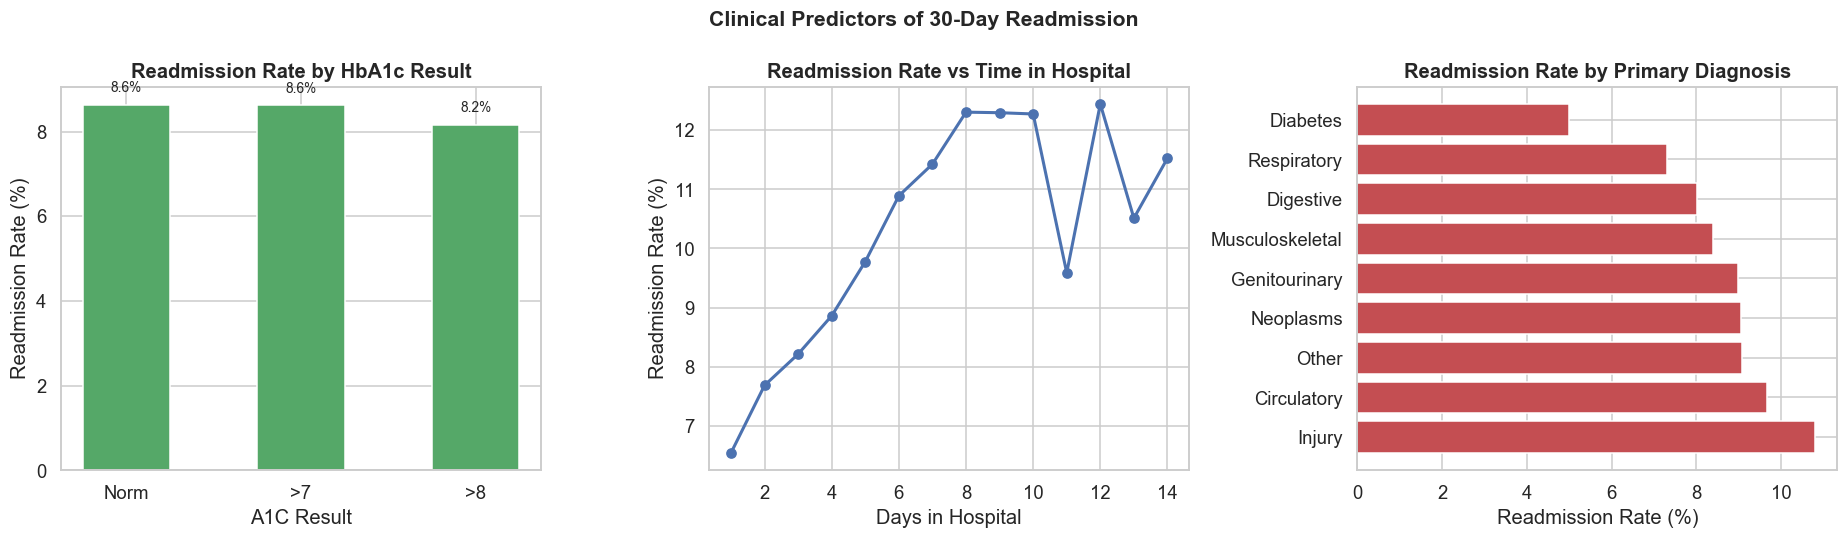

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# A1C result
a1c_rate = df.groupby("A1Cresult")["readmit_30"].mean().sort_values(ascending=False) * 100
axes[0].bar(a1c_rate.index, a1c_rate.values, color="#55A868", edgecolor="white", width=0.5)
axes[0].set_title("Readmission Rate by HbA1c Result", fontweight="bold")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].set_xlabel("A1C Result")
for i, v in enumerate(a1c_rate.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
plt.savefig(
    "Outputs/figures/Readmission_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Readmission Rate by HbA1c Result Plot saved to outputs/figures/")
# Time in hospital
time_rate = df.groupby("time_in_hospital")["readmit_30"].mean() * 100
axes[1].plot(time_rate.index, time_rate.values, "o-", color="#4C72B0", lw=2, markersize=6)
axes[1].set_title("Readmission Rate vs Time in Hospital", fontweight="bold")
axes[1].set_xlabel("Days in Hospital")
axes[1].set_ylabel("Readmission Rate (%)")

plt.savefig(
    "Outputs/figures/Readmission_Rate_vs Time_in_Hospital.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Readmission Rate vs Time in Hospital Plot saved to outputs/figures/")
# Primary diagnosis category
diag_rate = df.groupby("diag_1_cat")["readmit_30"].mean().sort_values(ascending=False) * 100
axes[2].barh(diag_rate.index, diag_rate.values, color="#C44E52", edgecolor="white")
axes[2].set_title("Readmission Rate by Primary Diagnosis", fontweight="bold")
axes[2].set_xlabel("Readmission Rate (%)")

plt.savefig(
    "Outputs/figures/Readmission Rate_by_Primary_Diagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Readmission Rate by Primary Diagnosis Plot saved to outputs/figures/")

plt.suptitle("Clinical Predictors of 30-Day Readmission", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Encode Categoricals & Build Model Dataset

In [11]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Drop raw medication columns — we captured them in aggregate features
df_model.drop(columns=med_cols, inplace=True)

# Drop raw age (we have age_numeric)
df_model.drop(columns=["age"], inplace=True)

# Encode remaining object columns
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print(f"\n✅ All categoricals encoded")
print(f"   Final dataset: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")
df_model.head(3)

Categorical columns to encode: ['race', 'gender', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']

✅ All categoricals encoded
   Final dataset: 69,997 rows × 32 columns


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,prior_utilisation,num_diabetes_meds,num_med_changes,insulin_used,insulin_changed,long_stay,polypharmacy,a1c_tested,a1c_high,glucose_high
8,2,0,2,1,4,13,68,2,28,0,...,0,2,0,1,0,1,1,1,0,0
9,2,0,3,3,4,12,33,3,18,0,...,0,2,0,1,0,1,1,1,0,0
4,2,1,1,1,7,1,51,0,8,0,...,0,2,0,1,0,0,0,1,0,0


In [12]:
import pickle

# Separate features and target
feature_cols = [c for c in df_model.columns if c != "readmit_30"]
X = df_model[feature_cols]
y = df_model["readmit_30"]

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}  |  Positive rate: {y.mean()*100:.1f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {f}")

# Save for downstream notebooks
df_model.to_csv("readmission_model_data.csv", index=False)
pd.Series(feature_cols, name="feature").to_csv("../Data/Processed Data/feature_list.csv", index=False)
with open("../Outputs/Models/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("\n Saved: readmission_model_data.csv, feature_list.csv, encoders.pkl")

Feature matrix X : (69997, 31)
Target vector  y : (69997,)  |  Positive rate: 9.0%

Features (31):
   1. race
   2. gender
   3. admission_type_id
   4. discharge_disposition_id
   5. admission_source_id
   6. time_in_hospital
   7. num_lab_procedures
   8. num_procedures
   9. num_medications
  10. number_outpatient
  11. number_emergency
  12. number_inpatient
  13. number_diagnoses
  14. max_glu_serum
  15. A1Cresult
  16. change
  17. diabetesMed
  18. diag_1_cat
  19. diag_2_cat
  20. diag_3_cat
  21. age_numeric
  22. prior_utilisation
  23. num_diabetes_meds
  24. num_med_changes
  25. insulin_used
  26. insulin_changed
  27. long_stay
  28. polypharmacy
  29. a1c_tested
  30. a1c_high
  31. glucose_high

✅ Saved: readmission_model_data.csv, feature_list.csv, encoders.pkl


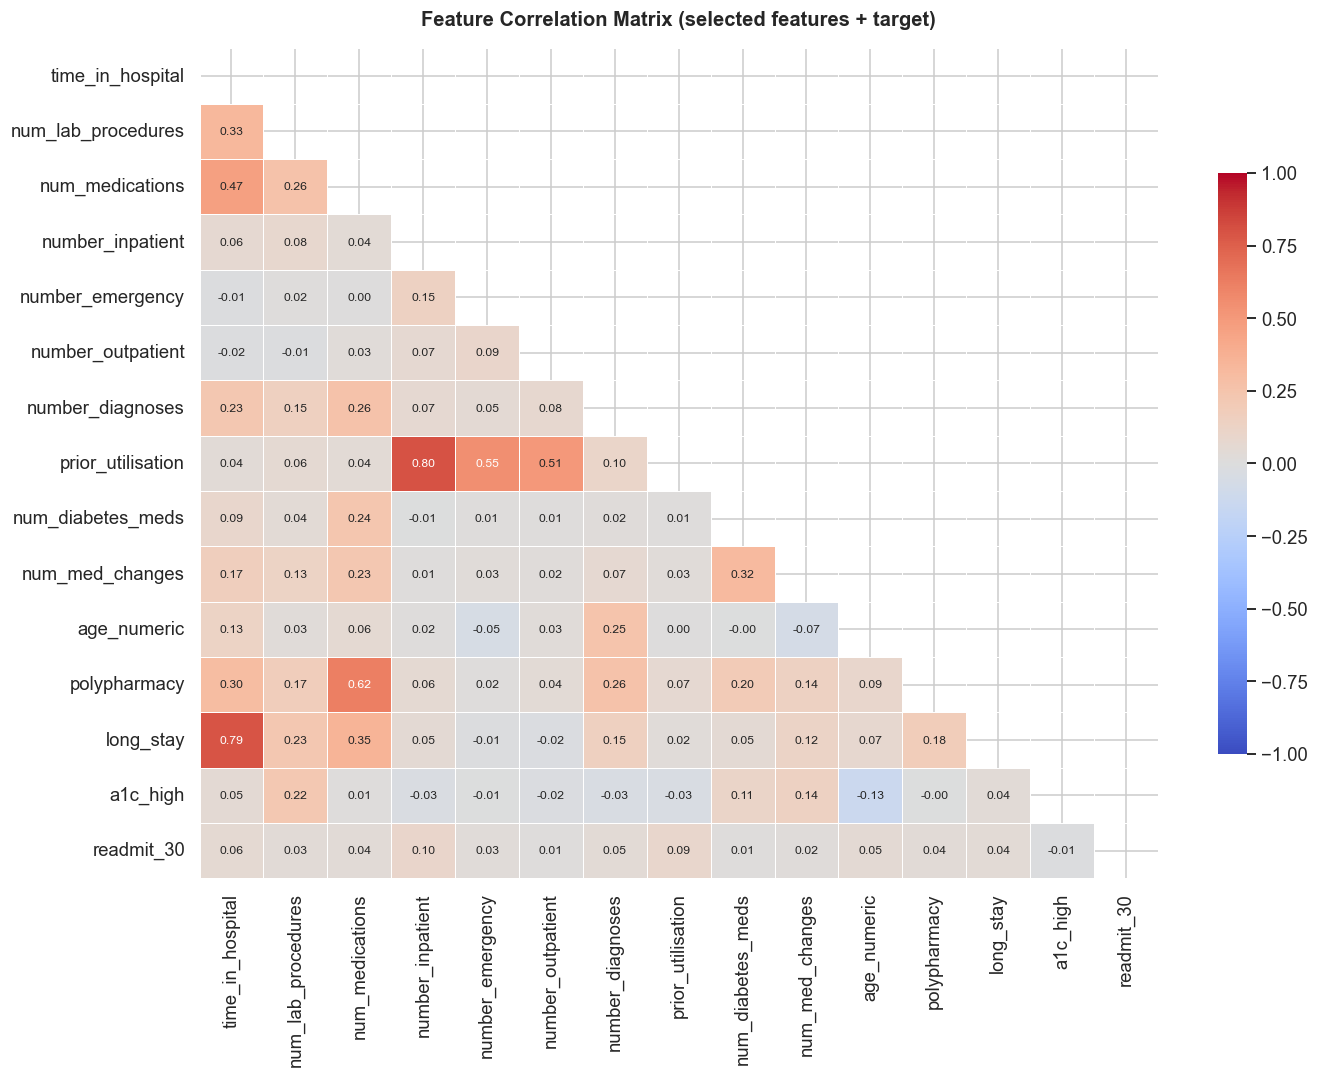


 Feature Correlation Matrix (selected features + target) Plot saved to outputs/figures/

Top 10 features correlated with 30-day readmission:
number_inpatient      0.1003
prior_utilisation     0.0862
time_in_hospital      0.0558
age_numeric           0.0471
number_diagnoses      0.0456
long_stay             0.0396
polypharmacy          0.0366
num_medications       0.0362
num_lab_procedures    0.0321
number_emergency      0.0280


<Figure size 1320x550 with 0 Axes>

In [14]:
# ── Correlation heatmap (top features) ───────────────────────────────────────
top_feats = ["time_in_hospital", "num_lab_procedures", "num_medications",
             "number_inpatient", "number_emergency", "number_outpatient",
             "number_diagnoses", "prior_utilisation", "num_diabetes_meds",
             "num_med_changes", "age_numeric", "polypharmacy",
             "long_stay", "a1c_high", "readmit_30"]

corr = df_model[top_feats].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.4,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix (selected features + target)",
             fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

plt.savefig(
    "Outputs/figures/Feature_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Feature Correlation Matrix (selected features + target) Plot saved to outputs/figures/")
# Top correlations with target
target_corr = corr["readmit_30"].drop("readmit_30").sort_values(key=abs, ascending=False)
print("\nTop 10 features correlated with 30-day readmission:")
print(target_corr.head(10).round(4).to_string())

---
## ✅ Notebook 1 Summary

| Step | Action | Outcome |
|------|--------|---------|
| Load | Read `diabetic_data.csv`, replace `?` → NaN | 101,766 rows × 50 cols |
| Clean | Drop weight/payer_code, remove deaths, keep first encounter | ~70,000 clean encounters |
| Target | Binarise `readmitted` → `<30` = 1 | ~11% positive rate |
| ICD-9 | Group 700+ codes into 9 clinical categories | `diag_1/2/3_cat` |
| Engineer | Prior utilisation, medication summary, clinical flags | +11 features |
| Encode | LabelEncode remaining categoricals | All numeric, model-ready |

**Strongest correlates with readmission:**
- `number_inpatient` (prior inpatient visits)
- `prior_utilisation` (composite score)
- `time_in_hospital`
